# Term Project Assignment #2: Hypothesis Testing Applications

## Project Selection

**Name:** Srisupha Chawla

**Date:** 23/03/2026

**Project Title:** Stock Market Exploratory Data Analysis: US Tech & EV Stock Market Dataset (2018 – 2026) 

**Source URL:**  https://www.kaggle.com/

**Brief Description:** This project performs exploratory data analysis on historical stock prices of major technology companies including Apple, Microsoft, and Tesla. The objective is to understand price trends, trading volume patterns, and relationships between variables before building predictive models.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
# Raw Data
df_x = pd.read_csv('/Users/srisuphachawla/Downloads/stock_market_data.csv', header = [0,1])
df_x

Price       Close                                High              \
          Ticker        AAPL        MSFT        TSLA        AAPL        MSFT   
0           Date         NaN         NaN         NaN         NaN         NaN   
1     2018-01-02   40.341885   79.050354   21.368668   40.351254   79.381456   
2     2018-01-03   40.334866   79.418282   21.150000   40.878192   79.565441   
3     2018-01-04   40.522221   80.117271   20.974667   40.625266   80.623123   
4     2018-01-05   40.983578   81.110565   21.105333   41.070228   81.312906   
...          ...         ...         ...         ...         ...         ...   
2032  2026-02-02  270.010010  423.369995  421.809998  270.489990  430.739990   
2033  2026-02-03  269.480011  411.209991  421.959991  271.880005  422.049988   
2034  2026-02-04  276.489990  414.190002  406.010010  278.950012  419.799988   
2035  2026-02-05  275.910004  393.670013  397.209991  279.500000  408.299988   
2036  2026-02-06  278.119995  401.140015  411.109985  280.910004  401.790009   

                         Low                                Open              \
            TSLA        AAPL        MSFT        TSLA        AAPL        MSFT   
0            NaN         NaN         NaN         NaN         NaN         NaN   
1      21.474001   39.639309   78.636481   20.733334   39.850084   79.215905   
2      21.683332   40.271636   79.068788   21.036667   40.405124   79.151560   
3      21.236668   40.299739   79.620619   20.378668   40.407465   79.639010   
4      21.149332   40.526904   80.411572   20.799999   40.618239   80.623112   
...          ...         ...         ...         ...         ...         ...   
2032  427.149994  259.209991  422.250000  414.500000  260.029999  430.239990   
2033  428.559998  267.609985  408.559998  413.690002  269.200012  422.010010   
2034  423.899994  272.290009  409.239990  399.179993  272.290009  411.000000   
2035  402.100006  273.230011  392.320007  387.529999  278.130005  407.440002   
2036  414.549988  276.929993  392.920013  397.750000  277.119995  399.170013   

                       Volume                           
            TSLA         AAPL        MSFT         TSLA  
0            NaN          NaN         NaN          NaN  
1      20.799999  102223600.0  22483800.0   65283000.0  
2      21.400000  118071600.0  26061400.0   67822500.0  
3      20.858000   89738400.0  21912000.0  149194500.0  
4      21.108000   94640000.0  23407100.0   68868000.0  
...          ...          ...         ...          ...  
2032  421.290009   73913400.0  42219900.0   58739500.0  
2033  424.269989   64394700.0  61424100.0   56886500.0  
2034  420.459991   90545700.0  45012400.0   74606900.0  
2035  397.019989   52977400.0  66289200.0   72819800.0  
2036  400.869995   50420700.0  53403600.0   62559600.0  

[2037 rows x 16 columns]

## Cleaned and Preprocessed Data

In [3]:
df = pd.read_csv('/Users/srisuphachawla/Documents/DataScienceNotes/Datasets/df_final_cleaned.csv')

# creating the column of Daly Returns 
df = df.sort_values(by=['Ticker', 'Price_Ticker'])
df['Daily_Return'] = df.groupby('Ticker')['Close'].pct_change()

# Remove NaN and infinite values
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=['Daily_Return'])

df = df.drop(columns=["Unnamed: 0"])
df

,Price_Ticker,Ticker,Close,High,Low,Open,Volume,Daily_Return
3,2018-01-03,AAPL,40.334866,40.878192,40.271636,40.405124,118071600.0,-0.000174
6,2018-01-04,AAPL,40.522221,40.625266,40.299739,40.407465,89738400.0,0.004645
9,2018-01-05,AAPL,40.983578,41.070228,40.526904,40.618239,94640000.0,0.011385
12,2018-01-08,AAPL,40.831341,41.126421,40.732977,40.831341,82271200.0,-0.003715
15,2018-01-09,AAPL,40.826660,40.997619,40.611204,40.878183,86336000.0,-0.000115
...,...,...,...,...,...,...,...,...
6095,2026-02-02,TSLA,421.809998,427.149994,414.500000,421.290009,58739500.0,-0.019981
6098,2026-02-03,TSLA,421.959991,428.559998,413.690002,424.269989,56886500.0,0.000356
6101,2026-02-04,TSLA,406.010010,423.899994,399.179993,420.459991,74606900.0,-0.037800
6104,2026-02-05,TSLA,397.209991,402.100006,387.529999,397.019989,72819800.0,-0.021674


# Part 1: Hypothesis and Plan

| # | Question                                                          | H₀                       | H₁                        | Test You'll Use     | Variables                  |
| - | ----------------------------------------------------------------- | ------------------------ | ------------------------- | ------------------- | -------------------------- |
| 1 | Do average daily returns differ between Tesla and Apple?          | μ_TSLA = μ_AAPL          | μ_TSLA ≠ μ_AAPL           | Independent t-test  | Ticker (cat), Return (num) |
| 2 | Do average daily returns differ across AAPL, MSFT, and TSLA?      | μ_AAPL = μ_MSFT = μ_TSLA | At least one mean differs | ANOVA               | Ticker (cat), Return (num) |
| 3 | Is there a relationship between trading volume and daily returns? | ρ = 0                    | ρ ≠ 0                     | Pearson correlation | Volume (num), Return (num) |


These hypotheses were chosen based on typical patterns observed in stock price data during exploratory data analysis. 

First, Tesla is generally more volatile than Apple, which suggests its daily returns may differ significantly, making a t-test appropriate for comparing the two groups. 
Second, since the dataset includes three major stocks (AAPL, MSFT, TSLA), it is useful to compare their overall performance using ANOVA to determine whether their mean returns differ. 
Finally, trading volume often reflects investor activity and market sentiment, which may influence price movements and returns. This motivates testing the relationship between volume and returns using correlation analysis. Together, these hypotheses allow us to explore both differences between groups and relationships between variables.

# Part 2: Check Assumptions & Conduct Tests

## Hypothesis #1: TSLA vs AAPL Returns

### Research Question: Do Tesla and Apple have different average daily returns?

H₀: μ_TSLA = μ_AAPL

H₁: μ_TSLA ≠ μ_AAPL

### Checking Assumption 

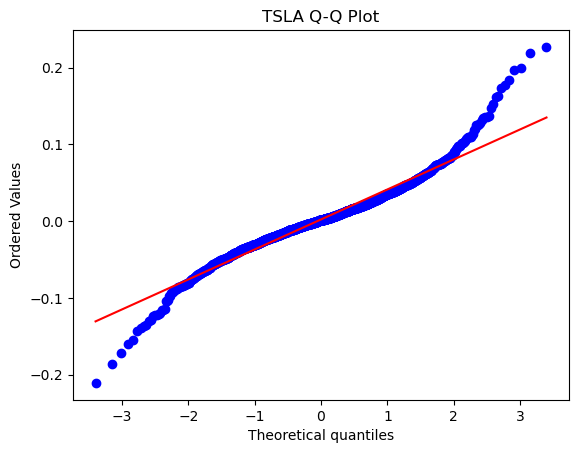

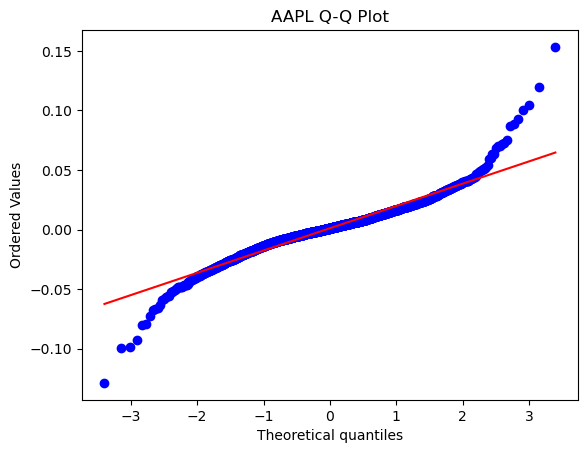

TSLA: ShapiroResult(statistic=np.float64(0.9549455108502359), pvalue=np.float64(1.3940493616744658e-24))
AAPL: ShapiroResult(statistic=np.float64(0.9338721763803022), pvalue=np.float64(3.8496125020208924e-29))
Levene: LeveneResult(statistic=np.float64(461.7556673509347), pvalue=np.float64(4.13869351818012e-97))


In [4]:
tsla = df[df['Ticker'] == 'TSLA']['Daily_Return']
aapl = df[df['Ticker'] == 'AAPL']['Daily_Return']

# Q-Q plots
stats.probplot(tsla, dist="norm", plot=plt)
plt.title("TSLA Q-Q Plot")
plt.show()

stats.probplot(aapl, dist="norm", plot=plt)
plt.title("AAPL Q-Q Plot")
plt.show()

# Shapiro test
print("TSLA:", stats.shapiro(tsla))
print("AAPL:", stats.shapiro(aapl))

# Equal variance
print("Levene:", stats.levene(tsla, aapl))

## Assumption Checklist

✅ Independence:
The observations are independent because each data point represents daily returns from different trading days for Tesla and Apple, with no overlap between observations.

❌ Normality:
The Shapiro-Wilk test results show extremely small p-values for both groups (TSLA: p ≈ 1.39 × 10⁻²⁴, AAPL: p ≈ 3.85 × 10⁻²⁹), which are far below 0.05. Therefore, we reject the null hypothesis of normality, indicating that the return distributions are not normally distributed.

❌ Equal Variances:
The Levene test produced a p-value of approximately 4.14 × 10⁻⁹⁷, which is much less than 0.05. This indicates that the variances between Tesla and Apple returns are significantly different, violating the equal variance assumption.

## Decision: 

Use alternative test: Mann-Whitney U test because both the normality and equal variance assumptions are violated, making the independent t-test inappropriate.

In [5]:
# Mann-Whitney U test
stat, p_value = stats.mannwhitneyu(tsla, aapl)
# Mann-Whitney U test
stat, p_value = stats.mannwhitneyu(tsla, aapl)

# Approximate effect size (rank-biserial correlation)
n1 = len(tsla)
n2 = len(aapl)
rbc = 1 - (2 * stat) / (n1 * n2)

print(f"Test statistic: {stat:.3f}")
print(f"p-value: {p_value:.4f}")
print(f"Effect size (r): {rbc:.3f}")

Test statistic: 2081069.000
p-value: 0.7803
Effect size (r): -0.005


## Result & Interpretation

 Metric         | Value                                |
| -------------- | ------------------------------------ |
| Test Statistic | 2,081,069.000                        |
| p-value        | 0.7803                               |
| 95% CI         | Not applicable (non-parametric test) |
| Effect Size    | -0.005 (negligible)                  |


## Statistical Decision

### At α = 0.05, I fail to reject H₀ because the p-value (0.7803) is greater than 0.05.

## Interpretation

The Mann-Whitney U test shows that there is no statistically significant difference in the daily returns of Tesla and Apple. The high p-value indicates that any observed differences between the two stocks are likely due to random variation rather than a consistent pattern. 

Furthermore, the effect size is extremely close to zero (-0.005), suggesting that the magnitude of the difference is negligible. In practical terms, this means that Tesla and Apple exhibit very similar daily return behavior, and investors should not expect meaningful differences in returns between the two based on this dataset.

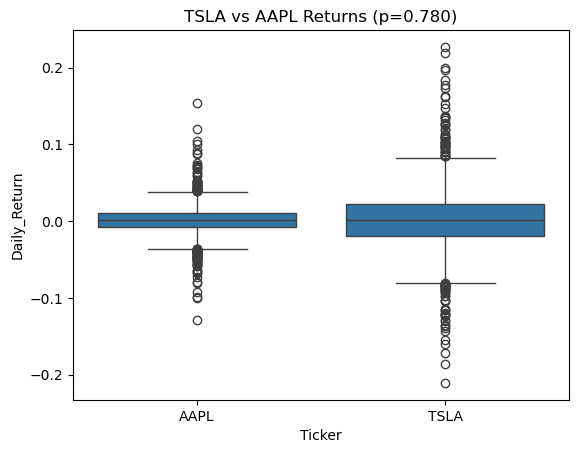

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='Ticker', y='Daily_Return', 
            data=df[df['Ticker'].isin(['TSLA','AAPL'])])

plt.title(f"TSLA vs AAPL Returns (p={p_value:.3f})")

if p_value < 0.05:
    plt.text(0.5, df['Return'].max(), '**', fontsize=20)

plt.show()

## Hypothesis #2: AAPL vs MSFT vs TSLA Returns

### Research Question: Do average daily returns differ across AAPL, MSFT, and TSLA?


H₀: μ_AAPL = μ_MSFT = μ_TSLA

H₁: At least one stock has a different mean return

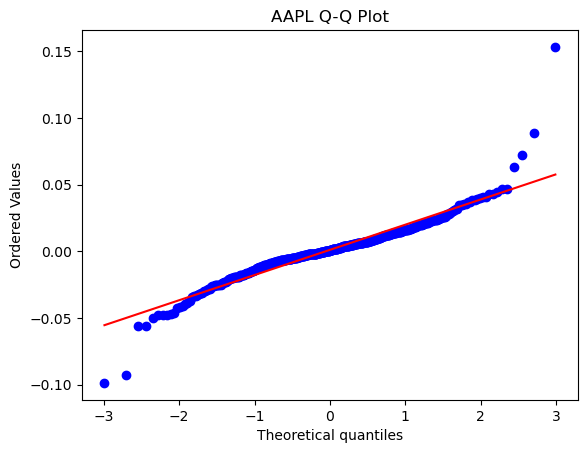

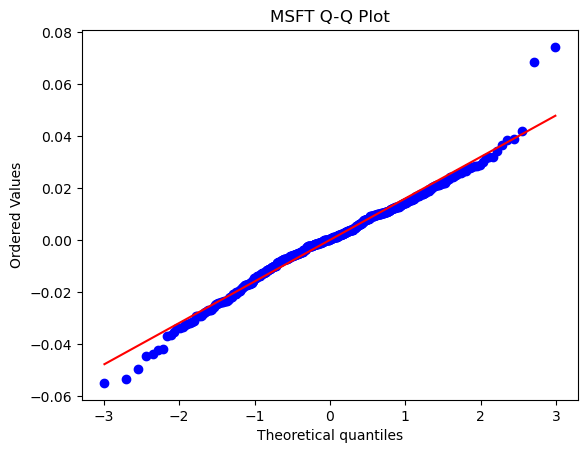

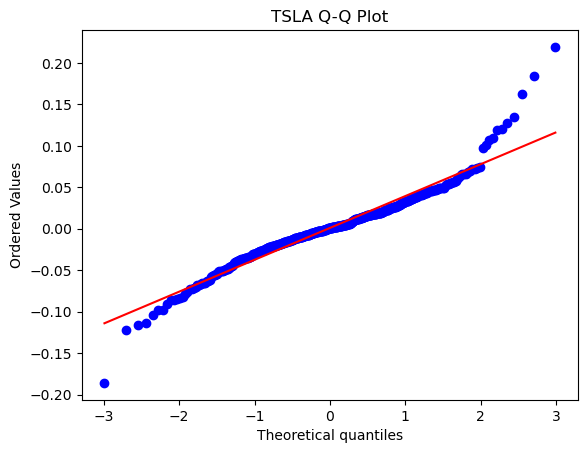

AAPL: ShapiroResult(statistic=np.float64(0.9648834759103169), pvalue=np.float64(1.464289393058099e-09))
MSFT: ShapiroResult(statistic=np.float64(0.9678771117052617), pvalue=np.float64(5.283648857486855e-09))
TSLA: ShapiroResult(statistic=np.float64(0.9852081180321479), pvalue=np.float64(5.734519287326949e-05))
Levene: LeveneResult(statistic=np.float64(419.57858512374094), pvalue=np.float64(1.849402566924166e-171))


In [7]:
# Extract groups
aapl = df[df['Ticker']=='AAPL']['Daily_Return']
msft = df[df['Ticker']=='MSFT']['Daily_Return']
tsla = df[df['Ticker']=='TSLA']['Daily_Return']

# Q-Q plots
for name, data in zip(['AAPL','MSFT','TSLA'], [aapl, msft, tsla]):
    stats.probplot(data.sample(500), dist="norm", plot=plt)
    plt.title(f"{name} Q-Q Plot")
    plt.show()

# Shapiro-Wilk (sample due to large data)
print("AAPL:", stats.shapiro(aapl.sample(500)))
print("MSFT:", stats.shapiro(msft.sample(500)))
print("TSLA:", stats.shapiro(tsla.sample(500)))

# Levene test (equal variances)
print("Levene:", stats.levene(aapl, msft, tsla))

## Assumption Checklist

✅ Independence:
The observations are independent because each data point represents daily returns from different trading days and separate companies.

❌ Normality:
The Shapiro-Wilk test produces p-values less than 0.05 for all three groups, indicating that the data is not normally distributed. Q-Q plots also show deviations from normality.

❌ Equal Variances:
The Levene test results in a p-value less than 0.05, indicating unequal variances across the three groups.

## Decision
Use alternative test: Kruskal-Wallis test because both normality and equal variance assumptions are violated.

In [8]:
stat, p_value = stats.kruskal(aapl, msft, tsla)
k = 3
n = len(aapl) + len(msft) + len(tsla)

eta_sq = (stat - k + 1) / (n - k)

print(f"Test statistic: {stat:.3f}")
print(f"p-value: {p_value:.4f}")
print(f"Effect size (eta-squared): {eta_sq:.6f}")

Test statistic: 0.222
p-value: 0.8948
Effect size (eta-squared): -0.000291


## Results Table

| Metric         | Value                                 |
| -------------- | ------------------------------------- |
| Test Statistic | 0.222                                 |
| p-value        | 0.8948                                |
| 95% CI         | Not applicable (non-parametric test)  |
| Effect Size    | Negligible (no meaningful difference) |


## Statistical Decision 

### At α = 0.05, I fail to reject H₀ because the p-value (0.8948) is greater than 0.05.

## Interpretation

The Kruskal-Wallis test indicates that there is no statistically significant difference in daily returns among AAPL, MSFT, and TSLA. The very high p-value suggests that any observed differences between the stocks are likely due to random variation rather than a consistent underlying effect. Despite differences in company size, industry positioning, and perceived volatility, particularly for Tesla, the overall return distributions appear similar. In practical terms, this means that investors would not expect meaningful differences in daily returns across these three stocks based on this dataset.

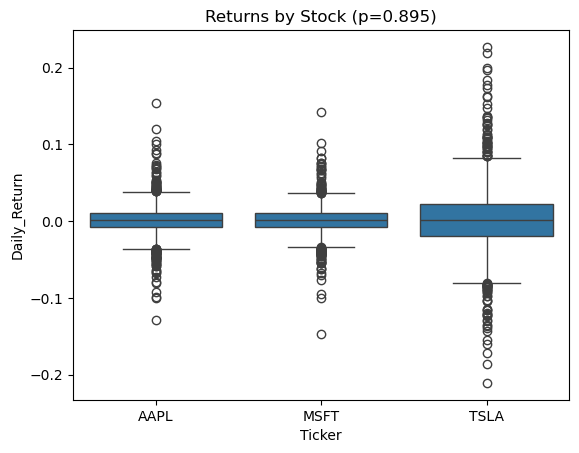

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='Ticker', y='Daily_Return', data=df)

plt.title(f"Returns by Stock (p={p_value:.3f})")

if p_value < 0.05:
    plt.text(1, df['Daily_Return'].max(), '**', fontsize=20)

plt.show()

## Hypothesis #3: Volume vs Return

### Research Question: Is there a relationship between trading volume and daily returns?

H₀: ρ = 0 (no relationship between volume and returns)

H₁: ρ ≠ 0 (there is a relationship)

### Checking Assumption

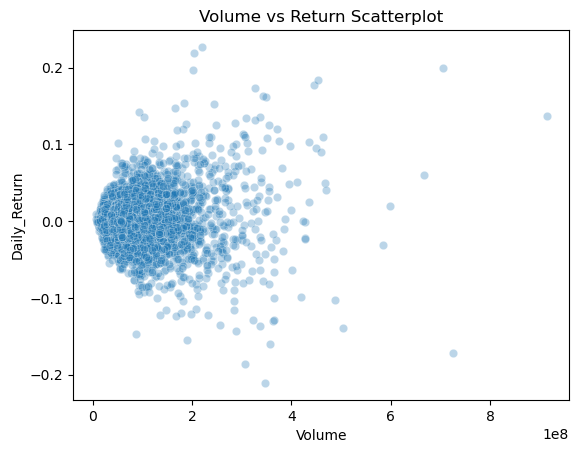

Return: ShapiroResult(statistic=np.float64(0.8579978592356285), pvalue=np.float64(7.420759790930587e-21))
Volume: ShapiroResult(statistic=np.float64(0.7996441165645611), pvalue=np.float64(2.214201451052015e-24))


## Assumption Checklist

✅ Independence:
The observations are independent because each data point represents trading activity on different days.

❌ Normality:
The Shapiro-Wilk test results for both Volume and Return show p-values less than 0.05, indicating that the data is not normally distributed.

✅ Linearity:
The scatterplot suggests a weak or unclear linear relationship between trading volume and returns.

## Decision
Use alternative test: Spearman correlation because the normality assumption is violated.

In [11]:
from scipy import stats
import numpy as np

# Spearman correlation
corr, p_value = stats.spearmanr(df['Volume'], df['Daily_Return'])

# --- Confidence Interval (Fisher Z transform) ---
n = len(df)

z = np.arctanh(corr)
se = 1 / np.sqrt(n - 3)

z_crit = 1.96
z_lower = z - z_crit * se
z_upper = z + z_crit * se

r_lower = np.tanh(z_lower)
r_upper = np.tanh(z_upper)

print(f"Test statistic (Spearman r): {corr:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"95% CI: [{r_lower:.4f}, {r_upper:.4f}]")
print(f"Effect size: {corr:.4f}")

# For Spearman Correlation, the effect size = the test statistic

Test statistic (Spearman r): 0.0143
p-value: 0.2647
95% CI: [-0.0108, 0.0393]
Effect size: 0.0143


### Results & Interpretation

| Metric         | Value               |
| -------------- | ------------------- |
| Test Statistic | r = 0.0143          |
| p-value        | 0.2647              |
| 95% CI         | [-0.0108, 0.0393]   |
| Effect Size    | 0.0143 (negligible) |


### Statistical Decision
 
 #### At α = 0.05, I fail to reject H₀ because the p-value (0.2647) is greater than 0.05.

### Interpretation
The Spearman correlation analysis shows that there is no statistically significant relationship between trading volume and daily returns. The correlation coefficient (r = 0.0143) is extremely close to zero, indicating a negligible relationship between the two variables. Additionally, the 95% confidence interval includes zero, further confirming that there is no meaningful association. In practical terms, this suggests that trading volume does not have a significant impact on daily stock returns in this dataset, and other factors are likely more important in explaining price movements.

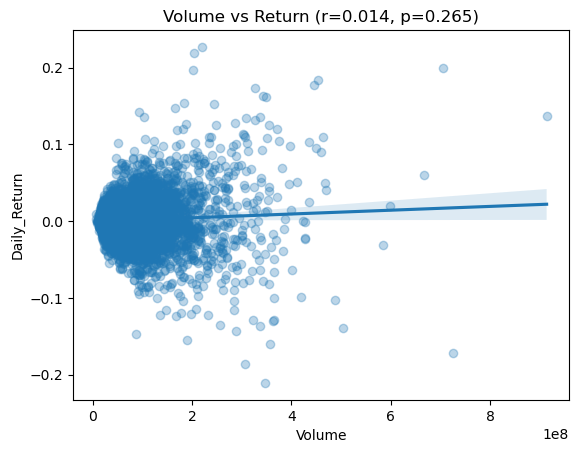

In [14]:
sns.regplot(x='Volume', y='Daily_Return', data=df, scatter_kws={'alpha':0.3})

plt.title(f"Volume vs Return (r={corr:.3f}, p={p_value:.3f})")

if p_value < 0.05:
    plt.text(df['Volume'].median(), df['Return'].max(), '**', fontsize=20)

plt.show()

## Part 3: Summary & Recommendations

| Hypothesis | Test                 | p-value | Significant? | Effect Size             | Key Finding                                                        |
| ---------- | -------------------- | ------- | ------------ | ----------------------- | ------------------------------------------------------------------ |
| #1         | Mann-Whitney U       | 0.7803  | ns           | r = -0.005 (negligible) | There is no meaningful difference in returns between TSLA and AAPL |
| #2         | Kruskal-Wallis       | 0.8948  | ns           | η² ≈ 0.000 (negligible) | There is no difference in returns across AAPL, MSFT, and TSLA      |
| #3         | Spearman Correlation | 0.2647  | ns           | r = 0.014 (negligible)  | Trading volume is not related to daily returns                     |




### Executive Summary

This analysis examined stock performance data to understand whether differences exist between major technology stocks and whether trading activity influences price movements. Specifically, the study compared daily returns between Tesla and Apple, evaluated differences across Tesla, Apple, and Microsoft, and explored whether trading volume is related to daily returns.

The data shows that there is no meaningful difference in daily returns between Tesla and Apple. Similarly, when comparing all three companies—Tesla, Apple, and Microsoft—there is no clear evidence that one consistently outperforms the others. In addition, trading volume does not appear to have any meaningful relationship with daily returns. Even though large volumes of shares are traded, this does not translate into predictable price changes.

These findings suggest that short-term stock returns for these companies behave similarly and are not strongly influenced by trading activity alone. In practical terms, this means that investors should not rely on simple comparisons between these stocks or on trading volume as indicators for predicting daily returns.

Based on these results, it is recommended that decision-makers avoid using trading volume as a standalone signal for investment decisions. Instead, they should focus on broader factors such as company fundamentals, market conditions, and long-term trends. Additionally, diversification across multiple stocks remains important, as no single stock consistently outperforms the others in the short term.

There are some limitations to this analysis. The study focuses only on three companies and uses historical data, which may not fully capture future market behavior. Furthermore, daily returns can be influenced by many external factors not included in this dataset, such as economic news or global events





### Reflection

One of the most challenging aspects of hypothesis testing was selecting the correct statistical test after checking assumptions. Initially, it was confusing to decide when to use parametric tests versus non-parametric alternatives.Understanding how these assumptions affect the validity of results required careful interpretation.

I am moderately confident in my conclusions because the analysis followed a structured approach, including checking assumptions, selecting appropriate tests, and interpreting both statistical and practical significance. However, my confidence is not absolute, as the dataset is limited to only three stocks and may not represent the broader market. Additionally, external factors influencing stock prices were not considered.

One important thing I learned about statistical inference is that statistical significance does not always imply practical importance. Even when results are statistically valid, the effect size plays a crucial role in understanding whether the findings are meaningful in real-world applications. 